In [61]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [62]:
df=pd.read_csv("../data/results.csv")
df.head()

,Unnamed: 0,Age,FirstTransactionDiff,LogAmount,MovingAvg,MovingStd,LogTimeDiff,Hour,TransactionTypeEntropy,ChannelEntropy,...,CityFreq,isoscores,aescores,somscores,scaledisoscores,scaledaescores,scaledsomscores,normisoscores,normaescores,normsomscores
0,745,29,56603.766667,6.976077,6.149854,1.457936,2.142025,13,0.856967,0.997786,...,0.884718,0.221687,0.027262,0.000506,0.221631,0.057817,0.077725,0.221687,0.070658,0.147512
1,746,29,56620.333333,6.487105,6.179942,1.463149,2.807393,6,0.856967,0.997786,...,0.884873,0.162806,0.039633,0.000750,0.162753,0.074968,0.031408,0.162806,0.077297,0.098432
2,747,29,56653.766667,6.562359,6.124093,1.435917,3.509553,15,0.856967,0.997786,...,0.885027,0.169400,0.033680,0.002694,0.169347,0.102077,0.056375,0.169400,0.093456,0.095766
3,748,29,56656.233333,6.849225,6.430966,1.304665,0.902868,18,0.856967,0.997786,...,0.885180,0.155502,0.046666,0.002865,0.155450,0.061261,0.034374,0.155502,0.059535,0.029172
4,749,29,56665.516667,7.594638,6.981384,0.607484,2.228221,3,0.856967,0.997786,...,0.885333,0.273435,0.062359,0.003418,0.273378,0.081181,0.088884,0.273435,0.110454,0.122936


In [63]:
df.shape

(210527, 29)

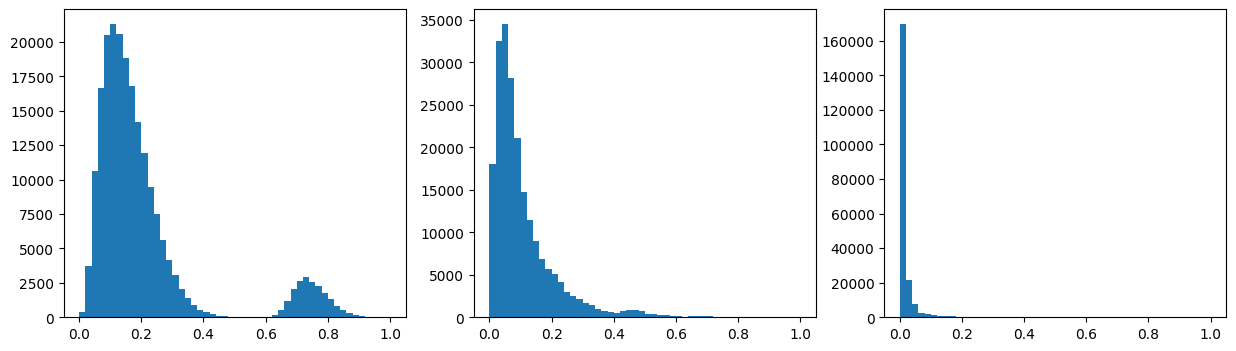

In [64]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(15,4))

axes[0].hist(df['isoscores'],bins=50)
axes[1].hist(df['aescores'],bins=50)
axes[2].hist(df['somscores'],bins=50)

plt.show()

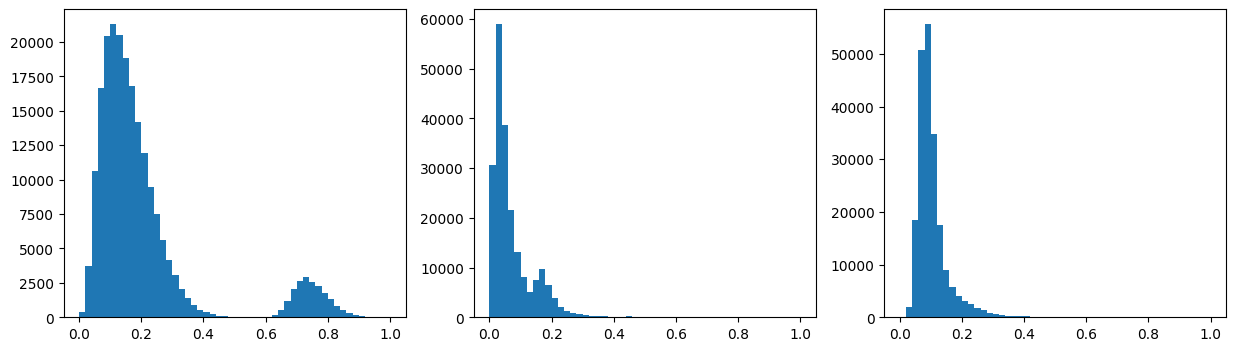

In [65]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(15,4))

axes[0].hist(df['scaledisoscores'],bins=50)
axes[1].hist(df['scaledaescores'],bins=50)
axes[2].hist(df['scaledsomscores'],bins=50)

plt.show()

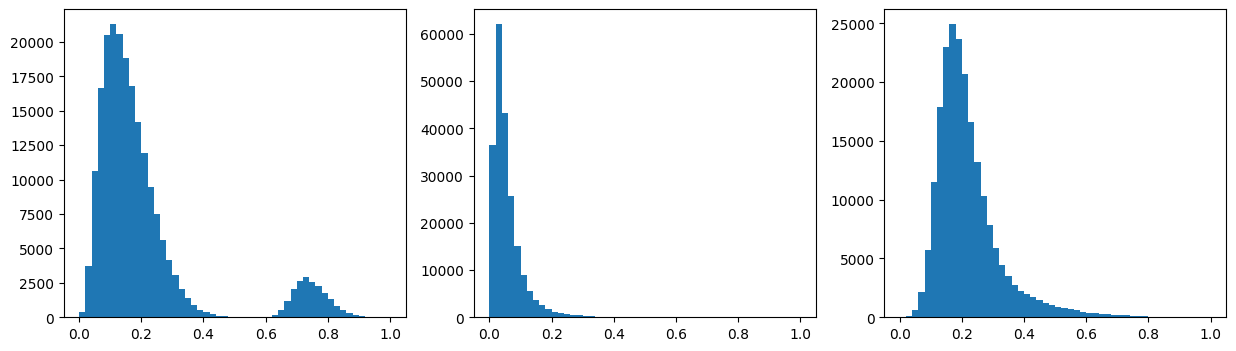

In [66]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(15,4))

axes[0].hist(df['normisoscores'],bins=50)
axes[1].hist(df['normaescores'],bins=50)
axes[2].hist(df['normsomscores'],bins=50)

plt.show()

In [67]:
corr=df[['isoscores','somscores','aescores']].corr(method='spearman')
corr

,isoscores,somscores,aescores
isoscores,1.000000,0.084685,0.161500
somscores,0.084685,1.000000,0.094401
aescores,0.161500,0.094401,1.000000


In [68]:
corr=df[['scaledisoscores','scaledsomscores','scaledaescores']].corr(method='spearman')
corr

,scaledisoscores,scaledsomscores,scaledaescores
scaledisoscores,1.000000,0.746359,0.624600
scaledsomscores,0.746359,1.000000,0.606707
scaledaescores,0.624600,0.606707,1.000000


In [69]:
corr=df[['normisoscores','normsomscores','normaescores']].corr(method='spearman')
corr

,normisoscores,normsomscores,normaescores
normisoscores,1.000000,0.707034,0.593350
normsomscores,0.707034,1.000000,0.535195
normaescores,0.593350,0.535195,1.000000


In [70]:
topscores=int(df.shape[0]*0.01)
isoresult=df.sort_values(by='isoscores',ascending=False).iloc[:topscores]
somresult=df.sort_values(by='somscores',ascending=False).iloc[:topscores]
aeresult=df.sort_values(by='aescores',ascending=False).iloc[:topscores]

overlap=len(set(isoresult.index)&set(aeresult.index)&set(somresult.index))/topscores
overlap*100

0.0

In [71]:
topscores=int(df.shape[0]*0.01)
isoresult=df.sort_values(by='scaledisoscores',ascending=False).iloc[:topscores]
somresult=df.sort_values(by='scaledsomscores',ascending=False).iloc[:topscores]
aeresult=df.sort_values(by='scaledaescores',ascending=False).iloc[:topscores]

overlap=len(set(isoresult.index)&set(aeresult.index)&set(somresult.index))/topscores
overlap*100

8.551068883610451

In [72]:
topscores=int(df.shape[0]*0.01)
isoresult=df.sort_values(by='normisoscores',ascending=False).iloc[:topscores]
somresult=df.sort_values(by='normsomscores',ascending=False).iloc[:topscores]
aeresult=df.sort_values(by='normaescores',ascending=False).iloc[:topscores]

overlap=len(set(isoresult.index)&set(aeresult.index)&set(somresult.index))/topscores
overlap*100

29.69121140142518

In [73]:
from scipy.stats import rankdata

def rank_normalize_df(df_scores):
    return df_scores.apply(lambda col: rankdata(col) / len(col))

In [74]:
def top_k_idx(series, k=0.01):
    n = len(series)
    k = int(n * k)
    return set(series.nlargest(k).index)

In [75]:
def top_k_overlap(df, col1, col2, k=0.01):
    top1 = top_k_idx(df[col1], k)
    top2 = top_k_idx(df[col2], k)
    return len(top1 & top2) / len(top1)

In [76]:
def overlap_matrix(df, cols, k=0.01):
    result = {}

    for c1 in cols:
        result[c1] = {}
        for c2 in cols:
            result[c1][c2] = top_k_overlap(df, c1, c2, k)

    return result

In [77]:
dfranked=rank_normalize_df(df)

In [78]:
cols = ['isoscores','somscores','aescores']
overlap=overlap_matrix(dfranked,cols)
overlap

{'isoscores': {'isoscores': 1.0,
  'somscores': 0.007600950118764846,
  'aescores': 0.07695961995249406},
 'somscores': {'isoscores': 0.007600950118764846,
  'somscores': 1.0,
  'aescores': 0.0014251781472684087},
 'aescores': {'isoscores': 0.07695961995249406,
  'somscores': 0.0014251781472684087,
  'aescores': 1.0}}

In [79]:
cols = ['scaledisoscores','scaledsomscores','scaledaescores']
overlap=overlap_matrix(dfranked,cols)
overlap

{'scaledisoscores': {'scaledisoscores': 1.0,
  'scaledsomscores': 0.6422802850356295,
  'scaledaescores': 0.11211401425178147},
 'scaledsomscores': {'scaledisoscores': 0.6422802850356295,
  'scaledsomscores': 1.0,
  'scaledaescores': 0.11211401425178147},
 'scaledaescores': {'scaledisoscores': 0.11211401425178147,
  'scaledsomscores': 0.11211401425178147,
  'scaledaescores': 1.0}}

In [80]:
cols = ['normisoscores','normsomscores','normaescores']
overlap=overlap_matrix(dfranked,cols)
overlap

{'normisoscores': {'normisoscores': 1.0,
  'normsomscores': 0.40427553444180525,
  'normaescores': 0.4812351543942993},
 'normsomscores': {'normisoscores': 0.40427553444180525,
  'normsomscores': 1.0,
  'normaescores': 0.41282660332541565},
 'normaescores': {'normisoscores': 0.4812351543942993,
  'normsomscores': 0.41282660332541565,
  'normaescores': 1.0}}